## **RNNs for Text Classification with Keras**


#### **Install Tensorflow**

In [0]:
!pip install --upgrade tensorflow

Requirement already up-to-date: tensorflow in /usr/local/lib/python3.6/dist-packages (2.2.0)


#### **Mount gdrive to colab**

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


#### **Check assigned GPU**

In [1]:
!nvidia-smi

Sun May 24 09:22:07 2020       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 440.82       Driver Version: 418.67       CUDA Version: 10.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0    27W / 250W |      0MiB / 16280MiB |      0%      Default |
+-------------------------------+----------------------+----------------------+
                                                                               
+-----------------------------------------------------------------------------+
| Processes:                                                       GPU Memory |
|  GPU  

#### **Download, unzip & load fasttext word embeddings**

In [0]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
!gzip -d cc.en.300.vec.gz

--2020-05-22 18:45:18--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 104.22.75.142, 104.22.74.142, 2606:4700:10::6816:4a8e, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|104.22.75.142|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1325960915 (1.2G) [binary/octet-stream]
Saving to: ‘cc.en.300.vec.gz’

cc.en.300.vec.gz    100%[===================>]   1.23G  10.4MB/s    in 2m 4s   

2020-05-22 18:47:24 (10.2 MB/s) - ‘cc.en.300.vec.gz’ saved [1325960915/1325960915]



#### **Load fasttext embeddings**
To load fasttext pre-trained embeddings more efficiently, we can read only once the embeddings file and save:

1. A 2D np-array for the embedding vectors
2. A dictionary that maps each word to the row index of its embedding on the 2D np-array

In [0]:
import pickle
import numpy as np

idx = 0
vocab = {}
with open("cc.en.300.vec", 'r', encoding="utf-8", newline='\n',errors='ignore') as f:
    for l in f:
        line = l.rstrip().split(' ')
        if idx == 0:
            vocab_size = int(line[0]) + 2
            dim = int(line[1])
            vecs = np.zeros(vocab_size*dim).reshape(vocab_size,dim)
            vocab["__PADDING__"] = 0
            vocab["__UNK__"] = 1
            idx = 2
        else:
            vocab[line[0]] = idx
            emb = np.array(line[1:]).astype(np.float)
            if (emb.shape[0] == dim):
                vecs[idx,:] = emb
                idx+=1
            else:
                continue

    pickle.dump(vocab,open("/content/gdrive/My Drive/fasttext_voc.pkl" ,'wb'))
    np.save("/content/gdrive/My Drive/fasttext.npy",vecs)
    # Free ram
    vecs = None
    vocab = None
    emb = None

#### **Load embeddings np-array and mapping dictionary**



In [0]:
import pickle
import numpy as np

fasttext_embed = np.load("/content/gdrive/My Drive/fasttext.npy")
fasttext_word_to_index = pickle.load(open("/content/gdrive/My Drive/fasttext_voc.pkl", 'rb'))

#### **Download  & explore 20newsgroups dataset**


In [4]:
from sklearn.datasets import fetch_20newsgroups
twenty_train = fetch_20newsgroups(subset='train')  #, remove=('headers', 'footers', 'quotes'))
print("Catergories")
print(twenty_train.target_names) #prints all the categories
print("-------------")
twenty_train.target_names 
print("First dataset's sample")
print("\n".join(twenty_train.data[0].split("\n")))
print("------------")
print("First dataset's sample category: ",twenty_train.target[0])

Catergories
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
-------------
First dataset's sample
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this 

#### **Split dataset into train (70%) & validation (30%)**

In [0]:
from sklearn.model_selection import train_test_split  
X_train, X_val, y_train, y_val = train_test_split(twenty_train.data, twenty_train.target, test_size=0.3, random_state=12547392)

In [6]:
len(X_train)

7919

#### **Use spacy for sentence splitting & tokenization**

In [0]:
import spacy
nlp = spacy.load('en_core_web_sm',disable=["tagger", "parser","ner"])
from spacy.lang.en.stop_words import STOP_WORDS
nlp.add_pipe(nlp.create_pipe('sentencizer')) 

X_train_tokenized = []
for idx in range(len(X_train)):
  doc = nlp(X_train[idx])
  tokens = []
  for sent in doc.sents:
    for tok in sent:
      if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or tok.text.lower() in STOP_WORDS:
        continue
      if tok.text.strip():  
        tokens.append(tok.text.replace('"',"'").strip())
  X_train_tokenized.append(tokens)

X_val_tokenized = []
for idx in range(len(X_val)):
  doc = nlp(X_val[idx])
  tokens = []
  for sent in doc.sents:
    for tok in sent:

      if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or tok.text.lower() in STOP_WORDS:
        continue
      if tok.text.strip():
        tokens.append(tok.text.replace('"',"'").strip())
  X_val_tokenized.append(tokens)

In [0]:
# Get mean and std for length on trainning set
print(np.mean([len(x) for x in X_train_tokenized]))
print(np.std([len(x) for x in X_train_tokenized]))
print(np.sum([len(x) > 1000 for x in X_train_tokenized]))


240.16517237024877
456.4071070866828
179


#### **Convert labels to 1-hot vectors**

In [0]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
target_list = twenty_train.target_names
y_train_1_hot = lb.fit_transform([target_list[x] for x in y_train])
y_val_1_hot = lb.transform([target_list[x] for x in y_val])

#### **Custom Keras callback for calculating f1, precision, recall at the end of each epoch** 

In [0]:
import tensorflow as tf
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np
import os


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_targ = self.validation_data[1]
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
            val_targ = np.argmax(val_targ, -1)
        val_targ = tf.cast(val_targ,dtype=tf.float32)
        

        _val_f1 = f1_score(val_targ, val_predict,average="weighted")
        _val_recall = recall_score(val_targ, val_predict,average="weighted")
        _val_precision = precision_score(val_targ, val_predict,average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

#### **Tokenize, convert text (sequence of words) to sequence of indexes and PAD the sequences**

In [0]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 1000
EMBEDDING_DIM = fasttext_embed.shape[1]
# Keras tokenizer uses \s for separating tokens
tokenizer = Tokenizer(num_words=MAX_WORDS,oov_token='__UNK__')
tokenizer.fit_on_texts([" ".join(x) for x in X_train_tokenized])
train_seqs = tokenizer.texts_to_sequences([" ".join(x) for x in X_train_tokenized])
val_seqs = tokenizer.texts_to_sequences([" ".join(x) for x in X_val_tokenized])
train_data = pad_sequences(train_seqs, maxlen=MAX_SEQUENCE_LENGTH,padding='post')
val_data = pad_sequences(val_seqs, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

In [12]:
print(train_data[349])

[37832 30704  6373     7   834    57 26052     6  4690  1877    25    20
    24  2535 30704  6373     7    61 37832 30704  6373     7     9 37833
  7494   185 30705   519     8    33  1196   841  3868  1063   477   487
   159  1923   220  3868  6612 17097   477  2028  1821    59 14794 53200
  1411  2664 30706  2856  5044    43   123  3436 22895  1413    33   123
   784 53201 30707  2759   854    91    41   139    27  6022  3868 30707
   581  5217  4007  2815  8488  2709  2430 37834  3011  1448  2317  1402
  4690  3706  1877    30 11670   834     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0   

In [13]:
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 101380 unique tokens.


#### **Initialize embedding matrix with fasttext pre-trained embedings**

In [0]:
embedding_matrix = np.zeros((MAX_WORDS+2, EMBEDDING_DIM))
for word, i in word_index.items():
    if i > MAX_WORDS:
            continue
    try:
        embedding_vector = fasttext_embed[fasttext_word_to_index[word],:]
        embedding_matrix[i] = embedding_vector
    except:
        pass

## **Create and train a BiGRU + MLP model**


In [0]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, GRU, Embedding
from tensorflow.keras.optimizers import Adam

GRU_SIZE = 300
DENSE = 1000

with tf.device('/device:GPU:0'):

  # create empty sequential model
  model = Sequential()
  # add an embedding layer
  model.add(Embedding(MAX_WORDS+2, EMBEDDING_DIM, weights=[embedding_matrix], 
                      input_length=MAX_SEQUENCE_LENGTH,mask_zero=True, trainable=False))
  # Use 0.33 dropout probabillity
  model.add(Dropout(0.33))
  # add a bidirectional gru layer with 0.33 variational (recurrent) dropout 
  model.add(Bidirectional(GRU(GRU_SIZE, return_sequences=False, recurrent_dropout = 0.33)))
  # add a hidden MLP layer
  model.add(Dropout(0.33))
  model.add(Dense(DENSE, activation='relu' ))
  # add the output MLP layer
  model.add(Dropout(0.33))
  model.add(Dense(len(twenty_train.target_names), activation='softmax'))

  print(model.summary())
  model.compile(loss='categorical_crossentropy',
                    optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])

  if not os.path.exists('/content/gdrive/My Drive/checkpoints'):
    os.makedirs('/content/gdrive/My Drive/checkpoints')

  checkpoint = ModelCheckpoint('/content/gdrive/My Drive/checkpoints/BiGRUMLP.hdf5',
                                                 monitor='val_f1', 
                                                 mode='max', verbose=2,
                                                 save_best_only=True,
                                                 save_weights_only=True)

  history = model.fit(train_data, y_train_1_hot,
                validation_data=(val_data, y_val_1_hot),
                batch_size=256,
                epochs=100,
                shuffle=True,
                callbacks=[Metrics(valid_data=(val_data, y_val_1_hot)),
                checkpoint])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 1000, 300)         30000600  
_________________________________________________________________
dropout (Dropout)            (None, 1000, 300)         0         
_________________________________________________________________
bidirectional (Bidirectional (None, 600)               1083600   
_________________________________________________________________
dropout_1 (Dropout)          (None, 600)               0         
_________________________________________________________________
dense (Dense)                (None, 1000)              601000    
_________________________________________________________________
dense_1 (Dense)              (None, 20)                20020     
Total params: 31,705,220
Trainable params: 1,704,620
Non-trainable params: 30,000,600
____________________________________

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 — val_f1: 0.125860 — val_precision: 0.305600 — val_recall: 0.156112

Epoch 00001: val_f1 improved from -inf to 0.12586, saving model to /content/gdrive/My Drive/checkpoints/BiGRUMLP.hdf5
31/31 [==============================] - 247s 8s/step - loss: 2.8765 - accuracy: 0.1095 - val_loss: 2.5987 - val_accuracy: 0.1561 - val_f1: 0.1259 - val_recall: 0.1561 - val_precision: 0.3056
Epoch 2/100
31/31 [==============================] - ETA: 0s - loss: 2.3674 - accuracy: 0.2325 — val_f1: 0.239331 — val_precision: 0.310047 — val_recall: 0.255081

Epoch 00002: val_f1 improved from 0.12586 to 0.23933, saving model to /content/gdrive/My Drive/checkpoints/BiGRUMLP.hdf5
31/31 [==============================] - 248s 8s/step - loss: 2.3674 - accuracy: 0.2325 - val_loss: 2.2674 - val_accuracy: 0.2551 - val_f1: 0.2393 - val_recall: 0.2551 - val_precision: 0.3100
Epoch 3/100
31/31 [==============================] - ETA: 0s - loss: 2.0744 - accuracy: 0.3252 — val_f1: 0.352856 — val_precision: 0.402787 — v

#### **Visualize Model's Training History**


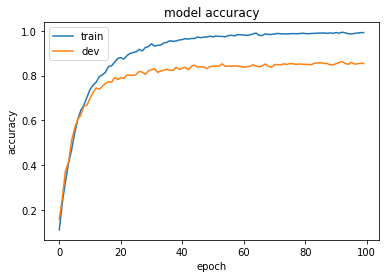

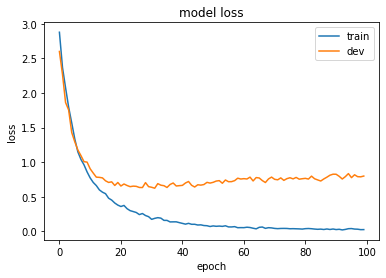

In [0]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

#### **Evaluate performance of BiGRU + MLP model on dev data**

In [0]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, GRU, Embedding
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report


GRU_SIZE = 300
DENSE = 1000

with tf.device('/device:GPU:0'):

  model = Sequential()
  model.add(Embedding(MAX_WORDS+2, EMBEDDING_DIM, weights=[embedding_matrix], 
                      input_length=MAX_SEQUENCE_LENGTH,mask_zero=True, trainable=False))
  model.add(Bidirectional(GRU(GRU_SIZE, return_sequences=False, recurrent_dropout = 0.33)))
  model.add(Dense(DENSE, activation='relu' ))
  model.add(Dense(len(twenty_train.target_names), activation='softmax'))
  #load weights from the pre-trained model
  model.load_weights("/content/gdrive/My Drive/checkpoints/BiGRUMLP.hdf5")
  
  predictions = np.argmax(model.predict(val_data), -1)
  print(classification_report(y_val, predictions, target_names=twenty_train.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.86      0.86      0.86       160
           comp.graphics       0.73      0.73      0.73       165
 comp.os.ms-windows.misc       0.81      0.80      0.81       189
comp.sys.ibm.pc.hardware       0.66      0.72      0.69       168
   comp.sys.mac.hardware       0.87      0.71      0.78       182
          comp.windows.x       0.90      0.89      0.89       168
            misc.forsale       0.78      0.80      0.79       182
               rec.autos       0.85      0.90      0.87       181
         rec.motorcycles       0.89      0.89      0.89       184
      rec.sport.baseball       0.94      0.94      0.94       169
        rec.sport.hockey       0.96      0.94      0.95       175
               sci.crypt       0.94      0.93      0.93       177
         sci.electronics       0.80      0.84      0.82       173
                 sci.med       0.92      0.96      0.94       181
         

#### **Custom keras layer for linear and deep self-attention over RNNs output states**

In [0]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import initializers, regularizers, constraints
from tensorflow.keras.layers import Layer
import numpy as np


def dot_product(x, kernel):
    """
    Wrapper for dot product operation, in order to be compatible with both
    Theano and Tensorflow
    Args:
        x (): input
        kernel (): weights
    Returns:
    """
    if K.backend() == 'tensorflow':
      return K.squeeze(K.dot(x, K.expand_dims(kernel)), axis=-1)
    else:
      return K.dot(x, kernel)


class LinearAttention(Layer):
    def __init__(self,
                 kernel_regularizer=None, bias_regularizer=None,
                 W_constraint=None, b_constraint=None,
                 bias=True,
                 return_attention=False,
                 **kwargs):
        
        self.supports_masking = True
        self.init = initializers.get('glorot_uniform')

        self.W_regularizer = regularizers.get(kernel_regularizer)
        self.b_regularizer = regularizers.get(bias_regularizer)

        self.W_constraint = constraints.get(W_constraint)
        self.b_constraint = constraints.get(b_constraint)

        self.bias = bias
        self.return_attention = return_attention
        super(LinearAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3

        self.W = self.add_weight(shape=(input_shape[-1],),
                                 initializer=self.init,
                                 name='{}_W'.format(self.name),
                                 regularizer=self.W_regularizer,
                                 constraint=self.W_constraint)
        if self.bias:
            self.b = self.add_weight(shape=(1,),
                                     initializer='zero',
                                     name='{}_b'.format(self.name),
                                     regularizer=self.b_regularizer,
                                     constraint=self.b_constraint)
        else:
            self.b = None

        self.built = True

    def compute_mask(self, inputs, mask=None):
        # do not pass the mask to the next layers
        if self.return_attention:
            return [None, None]
        return None

    def call(self, x, mask=None):
        
        # eij = Wx + b
        eij = dot_product(x, self.W)

        if self.bias:
            eij += self.b

        # Apply mask
        if mask is not None:
            eij *= K.cast(mask, K.floatx())

        # a = softmax(eij)
        a = K.expand_dims(K.softmax(eij, axis=-1))
        weighted_input = x * a
        result = K.sum(weighted_input, axis=1)

        if self.return_attention:
            return [result, a]
        return result

    def compute_output_shape(self, input_shape):
        if self.return_attention:
            return [(input_shape[0], input_shape[-1]),
                    (input_shape[0], input_shape[1])]
        else:
            return input_shape[0], input_shape[-1]


class DeepAttention(Layer):
    def __init__(self,
                 kernel_regularizer=None, u_regularizer=None, bias_regularizer=None,
                 W_constraint=None, u_constraint=None, b_constraint=None,
                 bias=True,
                 return_attention=False,
                 **kwargs):

        self.supports_masking = True
        self.init = initializers.get('glorot_uniform')

        self.W_regularizer = regularizers.get(kernel_regularizer)
        self.u_regularizer = regularizers.get(u_regularizer)
        self.b1_regularizer = regularizers.get(bias_regularizer)
        self.b2_regularizer = regularizers.get(bias_regularizer)

        self.W_constraint = constraints.get(W_constraint)
        self.u_constraint = constraints.get(u_constraint)
        self.b1_constraint = constraints.get(b_constraint)
        self.b2_constraint = constraints.get(b_constraint)

        self.bias = bias
        self.return_attention = return_attention
        super(DeepAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3

        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1],),
                                 initializer=self.init,
                                 name='{}_W'.format(self.name),
                                 regularizer=self.W_regularizer,
                                 constraint=self.W_constraint)
        if self.bias:
            self.b1 = self.add_weight(shape=(input_shape[-1],),
                                     initializer='zero',
                                     name='{}_b1'.format(self.name),
                                     regularizer=self.b1_regularizer,
                                     constraint=self.b1_constraint)
            self.b2 = self.add_weight(shape=(1,),
                                     initializer='zero',
                                     name='{}_b2'.format(self.name),
                                     regularizer=self.b2_regularizer,
                                     constraint=self.b2_constraint)
        else:
            self.b1 = None
            self.b2 = None

        self.u = self.add_weight(shape=(input_shape[-1],),
                                 initializer=self.init,
                                 name='{}_u'.format(self.name),
                                 regularizer=self.u_regularizer,
                                 constraint=self.u_constraint)

        self.built = True


    def compute_mask(self, inputs, mask=None):
        # do not pass the mask to the next layers
        if self.return_attention:
            return [None, None]
        return None

    def call(self, x, mask=None):
        # uit = tanh(Wx + b)
        uit = dot_product(x, self.W)

        if self.bias:
            uit += self.b1

        uit = K.tanh(uit)

        # ait = softmax(Ueij)
        eij = dot_product(uit, self.u)
        if self.bias:
            eij += self.b2

        # Apply mask
        if mask is not None:
            eij *= K.cast(mask, K.floatx())

        a = K.expand_dims(K.softmax(eij, axis=-1))
        
        weighted_input = x * a
        result = K.sum(weighted_input, axis=1)

        if self.return_attention:
            return [result, a]
        return result

    def compute_output_shape(self, input_shape):
        if self.return_attention:
            return [(input_shape[0], input_shape[-1]),
                    (input_shape[0], input_shape[1])]
        else:
            return input_shape[0], input_shape[-1]

#### **Create and train a BiLSTM + deep self-attention + MLP model**

In [0]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Embedding, Input
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras import Model



LSTM_SIZE = 300
DENSE = 1000

with tf.device('/device:GPU:0'):

  inputs = Input((MAX_SEQUENCE_LENGTH,))
  embeddings = Embedding(MAX_WORDS+2,EMBEDDING_DIM, weights=[embedding_matrix], 
                      input_length=MAX_SEQUENCE_LENGTH, mask_zero=True, trainable=False)(inputs)
  drop_emb = Dropout(0.33)(embeddings)
  bilstm = Bidirectional(LSTM(units=LSTM_SIZE, return_sequences=True,recurrent_dropout = 0.33))(drop_emb)
  drop_encodings = Dropout(0.33)(bilstm)
  x, attn = DeepAttention(return_attention=True)(drop_encodings)
  #x, attn = LinearAttention(return_attention=True)(drop_encodings)
  drop_x = Dropout(0.33)(x)
  hidden = Dense(units=DENSE, activation="relu")(drop_x)
  drop_out = Dropout(0.33)(hidden)
  out = Dense(units=len(twenty_train.target_names), activation="sigmoid")(drop_out)
  model2 = Model(inputs, out)
  print(model2.summary())

  model2.compile(loss='categorical_crossentropy',
                    optimizer=Adam(lr=0.001),
                    metrics=["accuracy"])

  if not os.path.exists('/content/gdrive/My Drive/checkpoints'):
    os.makedirs('/content/gdrive/My Drive/checkpoints')

  checkpoint = ModelCheckpoint('/content/gdrive/My Drive/checkpoints/BiLSTM_attn.hdf5',
                                                 monitor='val_f1', 
                                                 mode='max', verbose=2,
                                                 save_best_only=True,
                                                 save_weights_only=True)

  history2 = model2.fit(train_data, y_train_1_hot,
                validation_data=(val_data, y_val_1_hot),
                batch_size=128,
                epochs=100,
                shuffle=True,
                callbacks=[Metrics(valid_data=(val_data, y_val_1_hot)),
                checkpoint])

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 1000)]            0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 1000, 300)         30000600  
_________________________________________________________________
dropout (Dropout)            (None, 1000, 300)         0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, 1000, 600)         1442400   
_________________________________________________________________
dropout_1 (Dropout)          (None, 1000, 600)         0         
_________________________________________________________________
deep_attention (DeepAttentio [(None, 600), (None, 1000 361201    
_________________________________________________________________
dropout_2 (Dropout)          (None, 600)               0     

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 — val_f1: 0.211802 — val_precision: 0.328909 — val_recall: 0.240059

Epoch 00001: val_f1 improved from -inf to 0.21180, saving model to /content/gdrive/My Drive/checkpoints/BiLSTM_attn.hdf5
62/62 [==============================] - 549s 9s/step - loss: 2.6469 - accuracy: 0.1240 - val_loss: 2.3911 - val_accuracy: 0.2401 - val_f1: 0.2118 - val_recall: 0.2401 - val_precision: 0.3289
Epoch 2/100
62/62 [==============================] - ETA: 0s - loss: 1.9476 - accuracy: 0.3192 — val_f1: 0.417656 — val_precision: 0.528076 — val_recall: 0.463328

Epoch 00002: val_f1 improved from 0.21180 to 0.41766, saving model to /content/gdrive/My Drive/checkpoints/BiLSTM_attn.hdf5
62/62 [==============================] - 535s 9s/step - loss: 1.9476 - accuracy: 0.3192 - val_loss: 1.5803 - val_accuracy: 0.4633 - val_f1: 0.4177 - val_recall: 0.4633 - val_precision: 0.5281
Epoch 3/100
62/62 [==============================] - ETA: 0s - loss: 1.4459 - accuracy: 0.5009 — val_f1: 0.574949 — val_precision: 0.6133

#### **Evaluate performance of BiLSTM + deep self-attention + MLP model on dev data**


In [21]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, Embedding, Input
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras import Model
from sklearn.metrics import classification_report

LSTM_SIZE = 300
DENSE = 1000

with tf.device('/device:GPU:0'):

  inputs = Input((MAX_SEQUENCE_LENGTH,))
  embeddings = Embedding(MAX_WORDS+2,EMBEDDING_DIM, weights=[embedding_matrix], 
                      input_length=MAX_SEQUENCE_LENGTH, mask_zero=True, trainable=False)(inputs)
  bilstm = Bidirectional(LSTM(units=LSTM_SIZE, return_sequences=True,recurrent_dropout = 0.33))(embeddings)
  x, attn = DeepAttention(return_attention=True)(bilstm)
  hidden = Dense(units=DENSE, activation="relu")(x)
  out = Dense(units=len(twenty_train.target_names), activation="sigmoid")(hidden)
  model2 = Model(inputs, out)
  #load weights from the pre-trained model
  model2.load_weights("/content/gdrive/My Drive/checkpoints/BiLSTM_attn.hdf5")
  
  print("Dev set performance")
  predictions_val = np.argmax(model2.predict(val_data), -1)
  print(classification_report(y_val, predictions_val, target_names=twenty_train.target_names))

  print()
  print("Training set performance") # Overfitting on training set
  predictions_train = np.argmax(model2.predict(train_data), -1)
  print(classification_report(y_train, predictions_train, target_names=twenty_train.target_names))

Dev set performance
                          precision    recall  f1-score   support

             alt.atheism       0.93      0.81      0.87       160
           comp.graphics       0.82      0.78      0.80       165
 comp.os.ms-windows.misc       0.85      0.82      0.84       189
comp.sys.ibm.pc.hardware       0.65      0.73      0.69       168
   comp.sys.mac.hardware       0.82      0.79      0.81       182
          comp.windows.x       0.89      0.89      0.89       168
            misc.forsale       0.77      0.82      0.79       182
               rec.autos       0.92      0.88      0.90       181
         rec.motorcycles       0.94      0.90      0.92       184
      rec.sport.baseball       0.95      0.93      0.94       169
        rec.sport.hockey       0.95      0.95      0.95       175
               sci.crypt       0.96      0.94      0.95       177
         sci.electronics       0.81      0.87      0.84       173
                 sci.med       0.94      0.97      0.95

## **Resources**

*   https://github.com/keras-team/keras/tree/master/examples
*   https://keras.io/

